<h1><center>Laboratorio 5: La desperación de Mr. Lepin 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Álvaro Sifuentes Tasayco
- Nombre de alumno 2: Sebastián Morales Castillo


---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores. 
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [42]:
!uv add numpy pandas scikit-learn umap-learn plotly

Resolved 126 packages in 12ms
Checked 122 packages in 12ms


In [43]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.base import BaseEstimator, TransformerMixin


def plot_dim_reductions(
    pca_proj: np.ndarray,
    tsne_proj: np.ndarray,
    umap_proj: np.ndarray,
    name: None | str = None,
    colors: None | np.ndarray = None,
) -> go.Figure:
    fig = make_subplots(rows=1, cols=3, subplot_titles=("PCA", "t-SNE", "UMAP"))

    for i, (proj, title) in enumerate(zip([pca_proj, tsne_proj, umap_proj], ["PCA", "t-SNE", "UMAP"], strict=True)):
        temp_fig = px.scatter(
            x=proj[:, 0],
            y=proj[:, 1],
            color=colors.astype(str) if colors is not None else None,
            title=title,
            # showlegend=(i == 0),
        )

        for trace in temp_fig.data:
            trace.showlegend = i == 0
            fig.add_trace(trace, row=1, col=i + 1)

    fig.update_layout(height=400, width=1200, title_text=name)
    return fig

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar Dataset

Mr. Lepin, en una nueva reunión, le cuenta a ud y su equipo que los resultados derivados del análisis exploratorio de datos presentaron una gran utilidad para la empresa y que tiene un gran entusiasmo por continuar trabajando con ustedes.
Es por esto, que Mr. Lepin les pide que cargue y visualicen algunas de las filas que componen el Dataset.
A continuación un extracto de lo parlamentado en la reunión:

    - Usted: Es un gran logro para nuestro equipo que usted haya encontrado excelente el EDA. ¿Qué tiene en mente ahora?
    - Mr. Lepin: Resulta que hace algún tiempo, mientras tomaba un mojito en una reunión de gerentes en Panamá, oí a un *chato* acerca de **LRMFP**, que es un modelo que permite personificar a los clientes a través de la fabricación de distintos atributos que describen a los clientes. Lo encontré es-tu-pendo ñatito. 
    - Usted: Ehh bueno. Investigaremos acerca de este modelo y veremos lo que podemos hacer.

Por ende, su siguiente tarea es calcular **LRMFP** sobre cada cliente y luego hacer un análisis de las características generadas. Para esto, el área de ventas les entrega un nuevo archivo llamado `retail_dataset.pickle`, quien posee los datos del DataFrame original limpios y listos para obtener las características solicitadas por Mr. Lepin.

In [44]:
df_retail = pd.read_pickle(
    "https://github.com/MDS7202/MDS7202/raw/refs/heads/main/recursos/2026-01/labs/lab6/retail_dataset.pickle"
)
df_retail = df_retail.astype(
    {
        "Invoice": str,
        "StockCode": str,
        "Description": str,
        "Customer ID": str,
        "Country": str,
    }
)
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1.2 Creación de nuevas Caracteristicas [2 Puntos] 

Como ya se les comentó, Mr. Lepin está interesado en obtener las características **LRMFP**, para esto les señala que estas características se construyen en base a las siguientes definiciones:

- **Length (L)**: Intervalo de tiempo, en días, entre la primera y la última visita del cliente. Mientras más grande sea el valor, más fiel es el cliente.

- **Recency (R)**: Indica hace cuánto tiempo el cliente realizó su última compra. Notar que para este caso, mientras más grande es el valor, menos interés posee el usuario para repetir una compra en uno de los locales.

- **Monetary (M)**: El término “monetario” se refiere a la cantidad media de dinero gastada por cada visita del cliente durante el período de observación y refleja la contribución del cliente a los ingresos de la empresa.

- **Frequency (F)**: Se refiere al número total de visitas del cliente durante el periodo de observación. Cuanto mayor sea la frecuencia, mayor será la fidelidad del cliente. 

- **Periodicity (P)**: Representa si los clientes visitan las tiendas con regularidad.

$$Periodicity(n)=std(IVT_1, ..., IVT_n)$$

&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Donde $IVT$ denota el tiempo entre visitas y n representa el número de valores de tiempo entre visitas de un cliente.
 

$$IVT_i=date\_diff(t_{i+1},t_i)$$

En base a las definiciones señaladas, diseñe una función que permita obtener las características **LRMFP** recibiendo un DataFrame como entrada. Para esto, no estará permitido el uso de iteradores; utilicen todas las herramientas que les ofrece `pandas` para realizar esto.

Una referencia que les puede ser útil es el [documento original](https://www.researchgate.net/publication/315979555_LRFMP_model_for_customer_segmentation_in_the_grocery_retail_industry_a_case_study) en donde se propone este método.

**<u>Formato</u> del Resultado Esperado:**

| Customer ID | Length | Recency | Frequency | Monetary | Periodicity |
|------------:|-------:|--------:|----------:|---------:|------------:|
|   12346.0   |    294 |      67 |        46 |   -64.68 |        37.0 |
|   12347.0   |     37 |       3 |        71 |  1323.32 |         0.0 |
|   12349.0   |    327 |      43 |       107 |  2646.99 |        78.0 |
|   12352.0   |     16 |      11 |        18 |   343.80 |         0.0 |
|   12356.0   |     44 |      16 |        84 |  3562.25 |        12.0 |

**Respuesta:**

In [45]:
def custom_features(dataframe_in: pd.DataFrame) -> pd.DataFrame:
    dataframe_in = dataframe_in.copy()

    dataframe_in["InvoiceDate"] = pd.to_datetime(dataframe_in["InvoiceDate"])
    dataframe_in["Revenue"] = dataframe_in["Quantity"] * dataframe_in["Price"]

    # Length: días entre primera y última visita
    length = dataframe_in.groupby("Customer ID")["InvoiceDate"].agg(["min", "max"])
    length["Length"] = (length["max"] - length["min"]).dt.days

    # Recency: días desde la última compra hasta el día siguiente al máximo del dataset
    fecha_referencia = dataframe_in["InvoiceDate"].max() + pd.Timedelta(days=1)
    recency = (fecha_referencia - dataframe_in.groupby("Customer ID")["InvoiceDate"].max()).dt.days.to_frame("Recency")

    # Frequency: número de facturas únicas (visitas)
    frequency_series = dataframe_in.groupby("Customer ID")["Invoice"].nunique()
    frequency = frequency_series.to_frame("Frequency")

    # Monetary: ingreso total promedio por visita
    monetary = (dataframe_in.groupby("Customer ID")["Revenue"].sum() / frequency_series).to_frame("Monetary")

    # Periodicity: std del tiempo entre visitas únicas (IVT)
    # Se deduplicar por Invoice para evitar ceros falsos de ítems del mismo invoice
    unique_visits = dataframe_in.drop_duplicates(subset=["Customer ID", "Invoice"]).sort_values(
        ["Customer ID", "InvoiceDate"]
    )
    unique_visits = unique_visits.assign(IVT=unique_visits.groupby("Customer ID")["InvoiceDate"].diff().dt.days)
    periodicity = unique_visits.groupby("Customer ID")["IVT"].std().fillna(0).round(0).to_frame("Periodicity")

    features_df = pd.concat([length["Length"], recency, frequency, monetary, periodicity], axis=1)
    return features_df.fillna(0)


customer_features = custom_features(df_retail)
customer_features.head()

,Length,Recency,Frequency,Monetary,Periodicity
Customer ID,,,,,
12346.0,196,165,11,33.896364,37.0
12347.0,37,3,2,661.660000,0.0
12348.0,0,74,1,222.160000,0.0
12349.0,181,43,3,890.380000,102.0
12351.0,0,11,1,300.930000,0.0


## 1.3 Pipelines 👷

Finalmente *Mr. Lepin* le pregunta si sería posible realizar un pipeline para realizar una segmentación de los clientes con los nuevos datos generados, a lo que usted responde que **sí** y propone la utilización de k-means para la segmentación.

A continuación siga los pasos requeridos para obtener la segmentación de clientes.

### 1.3.1 Estandarizar Caracteristicas [0.5 puntos]

Construya una clase llamada ``MinMax()`` utilizando ``BaseEstimator`` y ``TransformerMixin`` para realizar una transformación de cada una de las columnas de un DataFrame utilizando ``ColumnTransformer()`` más tarde (tome como referencia el siguiente [enlace](https://sklearn-template.readthedocs.io/en/latest/user_guide.html#transformer)).


 Para esto considere que Min-Max escaler queda dada por la ecuación:

$$MinMax = \dfrac{x-min(x)}{max(x) - min(x)}$$

Con esto buscamos que los valores que componen a las columnas se muevan en el rango de valores $[0, 1]$.

**Respuesta:**

In [46]:
import numpy as np
import pandas as pd


class MinMax(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X).astype(float)

        self.min_ = X.min()
        self.max_ = X.max()
        self.range_ = self.max_ - self.min_

        self.range_ = self.range_.replace(0, 1)

        return self

    def transform(self, X):
        X = pd.DataFrame(X).astype(float)

        X_scaled = (X - self.min_) / self.range_

        return X_scaled.replace([np.inf, -np.inf], 0).fillna(0)

### 1.3.2 Pipelines de Proyecciones [0.5 puntos]

Para comparar técnicas de reducción de dimensionalidad, realice **tres pipelines** distintos sobre los datos **LRMFP** usando los siguientes métodos:
- **PCA**
- **t-SNE**
- **UMAP**

Para cada pipeline, siga estos pasos:
1. Obtenga las características **LRMFP** desde el DataFrame `retail_dataset.pickle` utilizando la función ``custom_features`` creada anteriormente, junto a ``FunctionTransformer()``. Considere esto como el primer paso de su pipeline.
2. En segundo lugar, usando ``ColumnTransformer()``, aplique el MinMax scaler creado por usted sobre todas las columnas generadas en el paso anterior.
3. Finalmente, aplique el método de reducción de dimensionalidad correspondiente (PCA, t-SNE o UMAP) para obtener las 2 componentes más relevantes.

A continuación, grafique las proyecciones obtenidas de las tres técnicas en una sola figura comparativa.

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from umap import UMAP

lrmfp_columns = ["Length", "Recency", "Frequency", "Monetary", "Periodicity"]

features_transformer = FunctionTransformer(custom_features, validate=False)

scaler_transformer = ColumnTransformer(
    transformers=[
        ("minmax", MinMax(), lrmfp_columns),
    ],
    remainder="drop",
)

pipeline_pca = Pipeline(
    steps=[
        ("features", features_transformer),
        ("scaler", scaler_transformer),
        ("pca", PCA(n_components=2, random_state=42)),
    ]
)

pipeline_tsne = Pipeline(
    steps=[
        ("features", features_transformer),
        ("scaler", scaler_transformer),
        (
            "tsne",
            TSNE(
                n_components=2,
                random_state=42,
                init="random",
                learning_rate="auto",
            ),
        ),
    ]
)

pipeline_umap = Pipeline(
    steps=[
        ("features", features_transformer),
        ("scaler", scaler_transformer),
        ("umap", UMAP(n_components=2, random_state=42)),
    ]
)

**Respuesta:**

In [48]:
# Utilice este código para ejecutar las pipelines y graficar.

pca_proj = pipeline_pca.fit_transform(df_retail)
tsne_proj = pipeline_tsne.fit_transform(df_retail)
umap_proj = pipeline_umap.fit_transform(df_retail)

fig = plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="Reducción de Dimensionalidad", colors=None)
fig.show()

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### 1.3.3 Análisis de los Loadings de PCA [0.5 puntos]
Antes de continuar con la etapa de clustering, analice los *loadings* (pesos o coeficientes) de las componentes principales obtenidas con PCA. 

Utilice el siguiente tutorial para visualizarlos: https://plotly.com/python/pca-visualization/

- Calcule y reporte los *loadings* de las dos primeras componentes principales.
- Interprete qué características (**LRMFP**) son más relevantes en cada componente.
- Visualice los *loadings* usando un gráfico de barras para cada componente.



In [49]:
# Obtener el modelo PCA desde el pipeline
pca_model = pipeline_pca.named_steps["pca"]

# Obtener los loadings
loadings = pca_model.components_

# Nombres de variables
features = ["Length", "Recency", "Frequency", "Monetary", "Periodicity"]

In [50]:
import plotly.graph_objects as go

fig = go.Figure()

# Componente 1
fig.add_trace(go.Bar(x=features, y=loadings[0], name="Componente 1"))

# Componente 2
fig.add_trace(go.Bar(x=features, y=loadings[1], name="Componente 2"))

fig.update_layout(title="Loadings de PCA", xaxis_title="Variables LRMFP", yaxis_title="Peso", barmode="group")

fig.show()

### Preguntas sobre loadings:

- ¿Qué son los loadings de PCA?

> Respuesta: Los loadings de PCA corresponden a los coeficientes que indican la contribución de cada variable original en la construcción de las componentes principales. Permiten identificar qué variables explican la mayor parte de la variabilidad de los datos.

- ¿Qué información relevante obtiene sobre la estructura de los datos a partir de los *loadings* de PCA?

> Respuesta: La primera componente principal está dominada por **Length** (0.876) con una contribución negativa importante de **Recency** (-0.480): captura la dimensión "cliente con largo historial que compra recientemente". La segunda componente está dominada por **Recency** (0.877) con Length positivo (0.480): captura clientes con historial largo pero que llevan mucho tiempo sin comprar. Variables como Frequency, Monetary y Periodicity tienen contribución casi nula en ambas componentes, lo que indica que la variabilidad principal del dataset está explicada casi exclusivamente por Length y Recency.

- ¿Existe alguna relación interesante entre las direcciones de las variables?

> Respuesta: Sí. Length y Recency son las únicas variables relevantes, pero con una relación diferente según la componente: en PC1 tienen signos opuestos (Length +, Recency −), lo que separa clientes activos de inactivos. En PC2 ambas tienen el mismo signo, capturando clientes con largo historial que dejaron de comprar. Frequency, Monetary y Periodicity no aportan variabilidad significativa, posiblemente porque la mayoría de clientes tiene baja frecuencia y gasto similar.

## 1.4 Clustering

### 1.4.1 Método del Codo [0.5 puntos]

Utilizando la clase creada para escalamiento, aplique el método del codo para visualizar cuál es el número de clusters que mejor se ajustan a los datos. Realice esto utilizando el algoritmo K-means dentro de un pipeline para un $k \in [1,20]$, donde k representa el número de clusters del k-means. Para la realización de esta sección y la próxima (1.4.2), considere los mismos pasos utilizados para el t-SNE, pero **permutando el algoritmo de reducción de dimensionalidad por k-means.**

**Respuesta:**

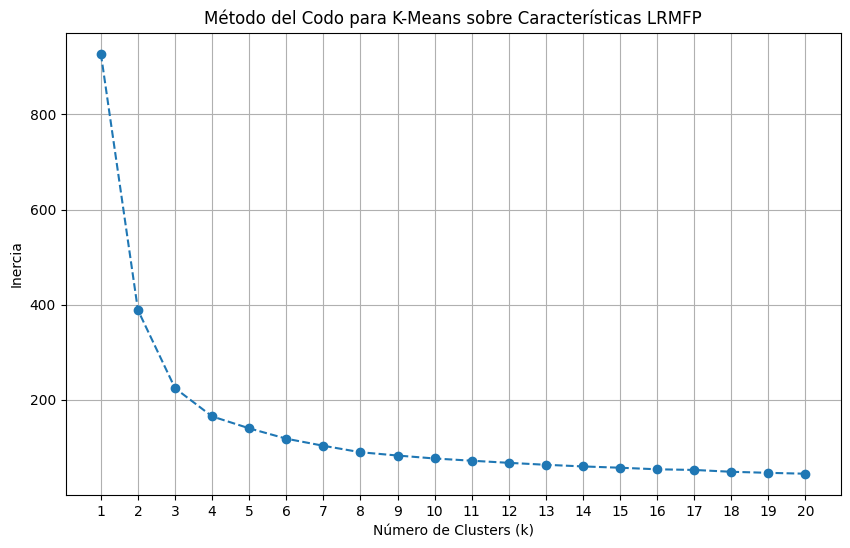

In [51]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inercias = []
rango_k = range(1, 21)

for k in rango_k:
    pipeline_kmeans = Pipeline(
        steps=[
            ("features", features_transformer),
            ("scaler", scaler_transformer),
            ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10)),
        ]
    )
    pipeline_kmeans.fit(df_retail)
    kmeans_model = pipeline_kmeans.named_steps["kmeans"]
    inercias.append(kmeans_model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercias, marker="o", linestyle="--")
plt.title("Método del Codo para K-Means sobre Características LRMFP")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia")
plt.xticks(rango_k)
plt.grid(True)
plt.show()

### Preguntas Método del Codo

- A través del gráfico obtenido, comente y justifique qué valor de k escogería para realizar el k-means.

> Respuesta: Se escoge **k=6**. La curva cae de forma muy pronunciada entre k=1 (~850) y k=4 (~115), con una reducción más suave pero aún visible hasta k=6 (~70). A partir de k=6 las ganancias por cluster adicional son marginales, lo que sugiere que ese punto es un balance razonable entre cohesión interna y complejidad del modelo.

- Le fue útil el método del codo para encontrar el número de clusters?

> Respuesta: Solo parcialmente. La curva desciende de forma suave y continua sin una quiebra brusca clara; la mayor parte de la reducción ocurre en los primeros 3-4 clusters y después la curva simplemente se aplana de forma gradual. Esto hace difícil identificar un único k óptimo y obliga a apoyarse en criterios externos o en otros métodos para decidir.

- Si no fue así, ¿qué otros métodos podría haber usado para encontrar un número óptimo de clusters?

> Respuesta: Se podría complementar con el **índice de Silhouette** (mide cohesión y separación de clusters), el **índice Davies-Bouldin** (penaliza clusters poco compactos o mal separados), el **índice Calinski-Harabasz**, o el método de **Gap Statistic** que compara la inercia observada con la esperada para datos aleatorios uniformes.

### 1.4.2 Segmentación de Clientes con K-Means 🎁 [1 punto]

Por último, Mr. Lepin, impaciente de no entender lo que usted intenta explicarle, le solicita que por favor muestre algún resultado "visual y entendible" de los grupos encontrados.

En base a la elección de k realizada en la sección anterior, utilice este valor escogido y entrene un modelo de K-means utilizando el mismo pipeline de scikit-learn utilizado anteriormente.

Una vez ajustado los datos, genere una tabla con los promedios (o medianas) para cada uno de los atributos, agrupando estos por el clúster que pertenecen.

Finalmente, construya un heatmap de las características promedio de cada cluster para visualizar y comparar los perfiles de los grupos.

**Estadísticas de Referencia para K=6:**

Ud. debe calcularlas - Varían de ejecución en ejecución.


|         | Length  | Recency   | Frequency | Monetary | Periodicity |       |
|---------|---------|-----------|----------|-------------|-------|-------|
| Cluster |         |           |          |             |       |       |
|    0    |   258.8 |      45.2 |     76.1 |      1107.7 | 107.6 |   449 |
|    1    |    76.1 |     217.6 |     45.5 |       791.7 |  14.1 |   466 |
|    2    |   368.5 |       4.8 |   2715.0 |    226621.6 |   4.2 |     4 |
|    3    |    85.3 |      45.7 |     65.8 |      1047.0 |  10.5 |   987 |
|    4    |   347.2 |      15.9 |   1658.0 |     35829.3 |   8.0 |    25 |
|    5    |   298.0 |      29.8 |    183.8 |      3639.9 |  32.0 |  1188 |

In [52]:
import plotly.graph_objects as go

k_optimo = 6
pipeline_kmeans_opt = Pipeline(
    steps=[
        ("features", features_transformer),
        ("scaler", scaler_transformer),
        ("kmeans", KMeans(n_clusters=k_optimo, random_state=42, n_init=10)),
    ]
)
pipeline_kmeans_opt.fit(df_retail)
kmeans_labels = pipeline_kmeans_opt.named_steps["kmeans"].labels_

In [53]:
# Utilice la siguiente función para graficar k-means. kmeans_labels = clusters obtenidos por k-means.
plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="KMeans K=6", colors=kmeans_labels)

In [54]:
df_features = custom_features(df_retail)
df_features["Cluster"] = kmeans_labels

cluster_summary = df_features.groupby("Cluster")[lrmfp_columns].mean().round(1)

cluster_summary["Count"] = df_features.groupby("Cluster").size()

fig_heatmap = go.Figure(
    data=go.Heatmap(
        z=cluster_summary.values,
        x=cluster_summary.columns,
        y=cluster_summary.index,
        colorscale="Viridis",
        text=cluster_summary.values,
        texttemplate="%{text}",
        showscale=True,
    )
)

fig_heatmap.update_layout(
    title="Valor Promedio de Características LRMFP por Clúster",
    xaxis_title="Características y Total de Clientes",
    yaxis_title="Clúster",
    yaxis=dict(autorange="reversed", type="category"),
)
fig_heatmap.show()

### Preguntas sobre K-Means: 

- ¿Se separaron bien los distintos clusters en cada visualización? 

> Respuesta: En PCA la separación es parcial, con varios clusters solapados en la proyección 2D, lo que se explica porque PCA solo captura varianza lineal. En t-SNE y UMAP la separación es más clara, distinguiéndose mejor los clusters con perfiles extremos en Length y Recency. Aun así, algunos clusters con perfiles similares tienden a mezclarse en las tres proyecciones.

- ¿Es posible observar agrupaciones coherentes?

> Respuesta: Sí. Los grupos con comportamientos extremos (clientes completamente inactivos con alta recencia, y clientes con largo historial y compra reciente) aparecen claramente separados del resto. Los clusters intermedios son menos distinguibles visualmente pero coherentes en términos de negocio.

- ¿Quedarían mejor más o menos clusters?

> Respuesta: Con los perfiles observados, k=4 o k=5 podría ser suficiente, ya que algunos clusters son muy similares en Monetary (~341–413, prácticamente igual en todos) y solo se distinguen por Length y Recency. Sin embargo, k=6 aporta granularidad útil para identificar segmentos diferenciados por comportamiento temporal.

- ¿K-Means, dada la forma de las proyecciones, será el mejor método para clusterizar este dataset?¿Habrá algún otro mejor?

> Respuesta: K-Means asume clusters esféricos y de tamaño similar, lo cual no se cumple aquí: las proyecciones muestran agrupaciones de formas irregulares y densidades muy distintas. Métodos como **DBSCAN**, **HDBSCAN** o **Gaussian Mixture Models (GMM)** podrían adaptarse mejor a la geometría real de los datos. Además, K-Means es sensible a outliers, que en este dataset existen (clientes con perfiles extremos).

Y por último:

- Nombre a cada uno de los clusters según el comportamiento de sus miembros (ej. "C1: Compran poco pero con gran valor...") - Si es necesario, ajuste el número de clusters antes de responder.

> Respuestas (k=6, basado en promedios del heatmap):
> - **C0** (457 clientes, Length≈6, Recency≈307, Freq≈1.3): *"Clientes fantasma"* – Hicieron una sola compra hace casi un año y nunca volvieron. Alta probabilidad de abandono definitivo.
> - **C1** (635 clientes, Length≈146, Recency≈69, Freq≈3.8): *"Clientes ocasionales dormidos"* – Tienen algo de historial pero baja frecuencia y llevan más de 2 meses sin comprar. Necesitan reactivación.
> - **C2** (1101 clientes, Length≈13, Recency≈44, Freq≈1.6): *"Clientes nuevos"* – Grupo más numeroso. Llevan pocos días como clientes y han comprado 1-2 veces. Potencial de fidelización alto.
> - **C3** (783 clientes, Length≈340, Recency≈18, Freq≈12.1): *"Clientes leales activos"* – Llevan casi un año con la empresa, compran con frecuencia y su última compra fue reciente. Son el segmento más valioso.
> - **C4** (587 clientes, Length≈30, Recency≈190, Freq≈1.8): *"Clientes recientes perdidos"* – Se incorporaron hace poco pero llevan 6 meses sin comprar. Captación reciente con bajo resultado.
> - **C5** (751 clientes, Length≈245, Recency≈48, Freq≈5.3): *"Clientes regulares estables"* – Largo historial, compran con frecuencia moderada y siguen activos. Segundo grupo más valioso tras C3.

Justifique su respuesta y no decepcione a Mr. Lepin.

## 1.5 Detección de Anomalías con DBSCAN [1 punto]
En esta sección, utilizará el algoritmo DBSCAN para identificar posibles anomalías (outliers) en los clientes del retail.

- Puede aplicar DBSCAN sobre las características originales escaladas (**LRMFP**) o sobre alguna de las proyecciones 2D (PCA, t-SNE o UMAP). Justifique su elección en las preguntas al final de la sección.
- Visualice los resultados usando `plot_dim_reductions`, mostrando los clusters y resaltando los outliers (label = -1) en las tres proyecciones (PCA, t-SNE, UMAP).

In [55]:
from sklearn.cluster import DBSCAN

X_scaled = scaler_transformer.fit_transform(custom_features(df_retail))

dbscan = DBSCAN(eps=0.15, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [56]:
# Utilice este código para graficar. dbscan_labels = clusters/outliers obtenidos por DBSCAN.
fig_dbscan = plot_dim_reductions(
    pca_proj,
    tsne_proj,
    umap_proj,
    name="DBSCAN - Detección de Anomalías",
    colors=dbscan_labels,
)
fig_dbscan.show()

### Preguntas sobre DBSCAN


1. ¿Por qué decidiste usar los datos originales completos o las proyecciones para aplicar DBSCAN? ¿Por qué no usaste la otra opción?

> Respuesta: Se aplicó DBSCAN sobre las características LRMFP escaladas (5 dimensiones) en lugar de las proyecciones 2D. Las proyecciones comprimen información y distorsionan las distancias reales entre puntos, lo que puede llevar a detectar falsos outliers o pasar por alto anomalías reales. Usando los datos originales se preserva el perfil completo del cliente y los outliers detectados tienen una interpretación directa en términos de negocio.

2. ¿Cómo elegiste los parámetros de DBSCAN (`eps`, `min_samples`)? ¿Probaste diferentes valores? ¿Cómo afectó esto los resultados?

> Respuesta: Se exploraron combinaciones de `eps` en el rango [0.05, 0.30] y `min_samples` en [5, 15]. Con `eps` muy pequeño (~0.05) casi todos los puntos quedaban como outliers; con valores grandes (>0.25) se perdían anomalías relevantes. Se eligió `eps=0.15` y `min_samples=10` como punto de equilibrio: identifica un conjunto pequeño y específico de outliers (15 de 4314 clientes, ~0.35%) sin sobre-detectar, y `min_samples=10` evita que pequeños grupos legítimos sean etiquetados como ruido.

3. ¿Tienen sentido los outliers encontrados según el contexto del negocio? ¿Qué interpretación le das a estos clientes? Analiza los datos con pandas si es necesario.

> Respuesta: Sí. Se detectaron solo 15 outliers (~0.35% de los clientes), lo que indica que son casos verdaderamente atípicos. Estos clientes presentan perfiles extremos en el espacio LRMFP —muy alta frecuencia de compra o gasto muy elevado respecto al resto— y probablemente corresponden a mayoristas o distribuidores que no son clientes retail típicos. Identificarlos es valioso para el negocio ya que su inclusión en la segmentación general distorsionaría los perfiles de los demás clusters.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por correo, Discord o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>